In [2]:
#models
library(tidyverse)
library(caret)
library(recipes)
library(pROC)
library(dplyr)
library(tidyr)
library(ppcor)
library(readxl)

dir.create("../../outputs/Fig3", recursive = TRUE, showWarnings = FALSE)


## Step 1: Load data

In [3]:
lucas_df_with_pcs <- read_csv("../../data/lucas_df_with_pcs.csv")
lucas_gemini_scores <- read_excel("../../data/lucas_gemini_scores.xlsx")

Rows: 287 Columns: 958
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (96): Patient, id, type, clinical_smokingstatus, QC, patient.type, cli...
dbl  (850): multinucratio, clinical_nlratio, clinical_CRP, clinical_cfdna_co...
lgl    (3): DIAGNOSE_OTHER_PRIMARY, Adaptor Dimer, Date Data Received
date   (9): DATE_1_VISIT_BBH, DATE_BIOPSY, DATE_SCAN_BASELINE, DATE_FEV1, DA...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
lucas_df_with_pcs <- merge(
  lucas_df_with_pcs,
  lucas_gemini_scores[, c("Patient ID", "GEMINI_score")],
  by.x = "Patient",
  by.y = "Patient ID",
  all.x = TRUE  # keeps all rows in lucas_df_with_pcs even if no match
)

## Statistical Modeling of Biologic Origin (copy number and mutational estimation)

In [5]:
# ============================================================
# ORIGIN SCORES - ORIGINAL |beta| ATTENUATION METHOD


library(tidyverse)

origin_scores_attenuation <- function(df,
                                      features,
                                      type_col   = "type",
                                      ichor_col  = "ichor",
                                      gemini_col = "GEMINI_score",
                                      use_abs    = FALSE) {

  model_df <- df %>%
    mutate(cancer_status = ifelse(.data[[type_col]] == "cancer", 1, 0))

  res <- map_dfr(features, function(feat) {

    d <- model_df %>%
      dplyr::select(cancer_status, all_of(c(feat, ichor_col, gemini_col))) %>%
      filter(if_all(everything(), ~ !is.na(.))) %>%
      mutate(
        x          = as.numeric(scale(if (use_abs) abs(.data[[feat]]) else .data[[feat]])),
        ichor_val  = .data[[ichor_col]],
        gemini_val = as.numeric(scale(.data[[gemini_col]]))
      )

    m1 <- suppressWarnings(glm(cancer_status ~ x,                          data = d, family = binomial))
    m2 <- suppressWarnings(glm(cancer_status ~ x + ichor_val + gemini_val, data = d, family = binomial))

    s1 <- coef(summary(m1))["x", ]
    s2 <- coef(summary(m2))["x", ]

    tibble(
      feature       = feat,
      feature_type  = if (grepl("^ratio_pc_", feat)) "PC" else "Z-score",
      spec          = if (use_abs) "|Z|" else "signed",
      pc            = suppressWarnings(as.integer(gsub("ratio_pc_", "", feat))),
      n             = nrow(d),
      beta          = unname(s1["Estimate"]),
      beta_adj      = unname(s2["Estimate"]),
      beta_se       = unname(s1["Std. Error"]),
      beta_adj_se   = unname(s2["Std. Error"]),
      beta_pval     = unname(s1["Pr(>|z|)"]),
      beta_adj_pval = unname(s2["Pr(>|z|)"]),
      delta_abs     = abs(unname(s2["Estimate"])) - abs(unname(s1["Estimate"])),
      se_ratio      = unname(s2["Std. Error"]) / unname(s1["Std. Error"])
    )
  })

  # MAD scaling within this call (feature class), as originally implemented
  s <- mad(res$delta_abs, constant = 1) + 1e-8

  res %>%
    mutate(
      mad_scale       = s,
      tumor_intrinsic = plogis(-delta_abs / s),
      tumor_extrinsic = plogis( delta_abs / s),
      total           = tumor_intrinsic + tumor_extrinsic,
      tumor_intrinsic = tumor_intrinsic / total,
      tumor_extrinsic = tumor_extrinsic / total
    ) %>%
    dplyr::select(-total)
}

# ---- Run ------------------------------------------------------------------
pc_features     <- grep("^ratio_pc_", names(lucas_df_with_pcs), value = TRUE)
zscore_features <- grep("^zscore_",   names(lucas_df_with_pcs), value = TRUE)

origin_scores_atten <- bind_rows(
  origin_scores_attenuation(lucas_df_with_pcs, pc_features,     use_abs = FALSE),
  origin_scores_attenuation(lucas_df_with_pcs, zscore_features, use_abs = TRUE)
) %>%
  group_by(feature_type) %>%
  mutate(
    beta_pval_fdr     = p.adjust(beta_pval,     method = "BH"),
    beta_adj_pval_fdr = p.adjust(beta_adj_pval, method = "BH")
  ) %>%
  ungroup() %>%
  mutate(
    call = case_when(
      tumor_intrinsic >= 0.6 ~ "Tumor-intrinsic",
      tumor_intrinsic <= 0.4 ~ "Tumor-extrinsic",
      TRUE                   ~ "Mixed"
    ),
    weak_unadj = beta_pval_fdr > 0.05
  )

stopifnot(!any(is.na(origin_scores_atten$tumor_intrinsic)))

cat("======== Attenuation method | PCs (signed) ========\n")
print(as.data.frame(
  origin_scores_atten %>% filter(feature_type == "PC") %>%
    arrange(desc(tumor_intrinsic)) %>%
    dplyr::select(feature, beta, beta_adj, delta_abs, se_ratio,
                  beta_pval_fdr, tumor_intrinsic, call, weak_unadj)),
  row.names = FALSE, digits = 3)

cat("\n======== Attenuation method | arm Z-scores (|Z|) ========\n")
print(as.data.frame(
  origin_scores_atten %>% filter(feature_type == "Z-score") %>%
    arrange(desc(tumor_intrinsic)) %>%
    dplyr::select(feature, beta, beta_adj, delta_abs, se_ratio,
                  beta_pval_fdr, tumor_intrinsic, call)),
  row.names = FALSE, digits = 3)

cat("\n======== Class summary ========\n")
print(as.data.frame(
  origin_scores_atten %>% group_by(feature_type) %>%
    summarise(n = n(), mad_scale = first(mad_scale),
              median_intrinsic = median(tumor_intrinsic),
              n_intrinsic = sum(call == "Tumor-intrinsic"),
              n_mixed     = sum(call == "Mixed"),
              n_extrinsic = sum(call == "Tumor-extrinsic"),
              median_se_ratio = median(se_ratio), .groups = "drop")),
  row.names = FALSE, digits = 3)

# ---- Side-by-side with the deviance partition -----------------------------
if (exists("origin_scores")) {
  cmp <- origin_scores %>%
    dplyr::select(feature, feature_type, ti_deviance = tumor_intrinsic,
                  call_deviance = call) %>%
    left_join(origin_scores_atten %>%
                dplyr::select(feature, ti_atten = tumor_intrinsic,
                              call_atten = call),
              by = "feature") %>%
    mutate(diff = ti_atten - ti_deviance,
           call_agrees = call_deviance == call_atten)

  cat("\n======== Deviance vs attenuation ========\n")
  print(as.data.frame(cmp %>% filter(feature_type == "PC") %>%
                        arrange(desc(ti_deviance))), row.names = FALSE, digits = 3)

  print(cmp %>% group_by(feature_type) %>%
          summarise(spearman = cor(ti_deviance, ti_atten, method = "spearman"),
                    pct_call_agree = mean(call_agrees),
                    median_abs_diff = median(abs(diff)), .groups = "drop"))
}

# write_csv(origin_scores_atten,
#           "../../outputs/Fig3/Supplementary-Origin-Scores-Attenuation.csv")

======== Attenuation method | PCs (signed) ========
     feature    beta beta_adj delta_abs se_ratio beta_pval_fdr tumor_intrinsic
 ratio_pc_01 -3.0152  -1.7458  -1.26942     1.20      6.61e-05        1.00e+00
 ratio_pc_02 -4.6896  -4.3752  -0.31441     1.13      1.60e-07        9.73e-01
 ratio_pc_03  0.0451   0.0482   0.00309     1.28      8.61e-01        4.91e-01
 ratio_pc_10  0.0112   0.0365   0.02534     1.94      9.25e-01        4.28e-01
 ratio_pc_11 -0.0479  -0.1064   0.05853     1.65      8.61e-01        3.39e-01
 ratio_pc_07  0.1343   0.2253   0.09097     2.12      5.16e-01        2.62e-01
 ratio_pc_09  0.0473   0.1804   0.13302     2.21      8.61e-01        1.80e-01
 ratio_pc_06  0.3200   0.4751   0.15512     1.52      3.45e-02        1.46e-01
 ratio_pc_08  0.2028   0.4822   0.27937     2.89      2.88e-01        4.00e-02
 ratio_pc_05 -0.0183   0.4588   0.44051     2.12      9.25e-01        6.61e-03
 ratio_pc_04  0.3771   1.2736   0.89651     1.93      2.93e-02        3.71e-05



Attaching package: ‘patchwork’


The following object is masked from ‘package:MASS’:

    area


Plotting origin scores from: attenuation (|beta|) method

10 retained, 0 zeroed features plotted.

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”


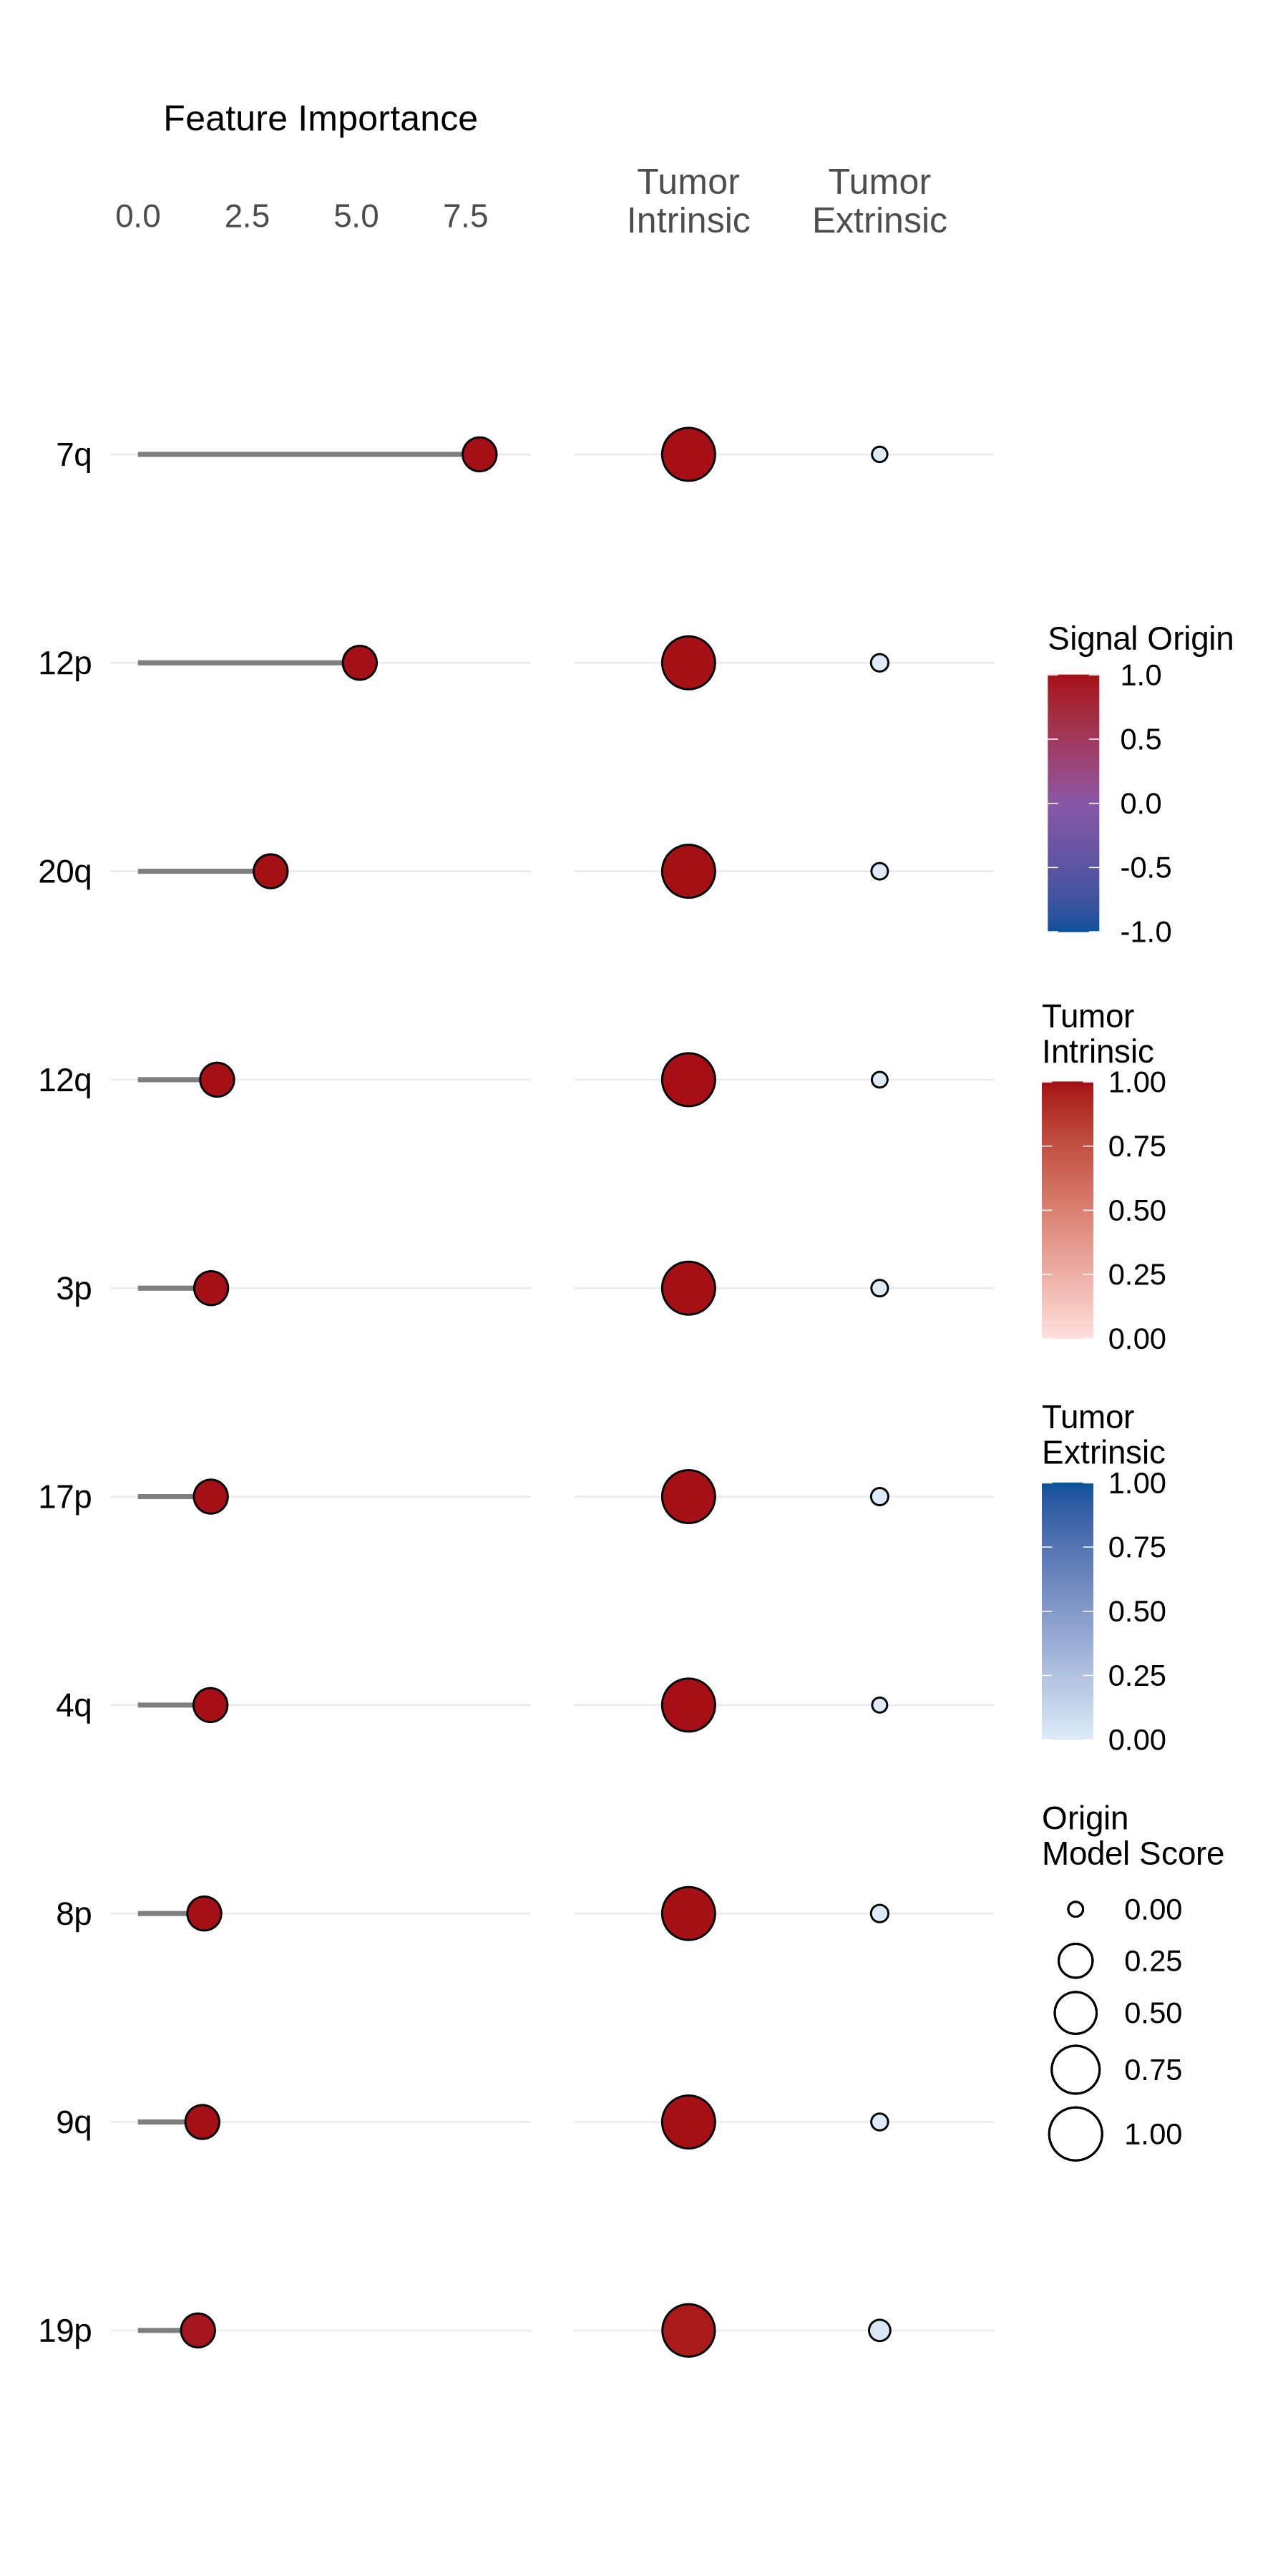

In [6]:
# ============================================================
# FIG 3g | FEATURE IMPORTANCE + MODELED SIGNAL ORIGIN

# ============================================================

library(tidyverse)
library(ggnewscale)
library(patchwork)

# ---- User arguments -------------------------------------------------------
n_features_to_plot <- 10
feature_prefixes   <- "zscore"     # or "zscore_"

# Show features with modeled origin scores that LASSO zeroed out, for
# reference. Applies to the PC panel only.
show_zeroed        <- TRUE
zeroed_to_show     <- c("ratio_pc_01")   # NULL = all zeroed features

# ---- Origin scores: |beta| attenuation method -----------------------------
score_src <- origin_scores_atten %>%
  dplyr::select(feature, tumor_intrinsic, tumor_extrinsic, weak_unadj)

message("Plotting origin scores from: attenuation (|beta|) method")

# ---- Extract and scale coefficients (Mathios method) ----------------------
model_mathios <- readRDS("../../data/mathios_classifier_seq.rds")

orig_coefs <- coef(model_mathios$finalModel, s = model_mathios$bestTune$lambda) * (-1)

pr_mathios  <- prep(model_mathios$recipe)
traindat    <- model_mathios$trainingData %>%
  mutate(id = factor(id), type = factor(type))
model_input <- bake(pr_mathios, new_data = traindat)

feature_sds <- model_input %>%
  dplyr::select(-c(id, type)) %>% as.data.frame() %>% summarise_all(sd)

feature_coefs <- merge(
  data.frame(feature = names(feature_sds), sd = as.numeric(feature_sds)),
  data.frame(feature = rownames(orig_coefs), orig_coefs = as.numeric(orig_coefs)),
  by = "feature", all.x = TRUE
)
feature_coefs$scaled_coefs <- feature_coefs$orig_coefs * feature_coefs$sd

# ---- Left panel: feature importance ---------------------------------------
feature_regex <- paste0("^(", paste(feature_prefixes, collapse = "|"), ")")

# Retained features (non-zero LASSO coefficient)
retained_df <- feature_coefs %>%
  as_tibble() %>%
  filter(!is.na(scaled_coefs), scaled_coefs != 0) %>%
  filter(str_detect(feature, feature_regex)) %>%
  mutate(importance = abs(scaled_coefs), retained = TRUE) %>%
  arrange(desc(importance)) %>%
  slice_head(n = n_features_to_plot)

# Zeroed features: present in the model matrix and scored, coefficient == 0
zeroed_df <- feature_coefs %>%
  as_tibble() %>%
  filter(str_detect(feature, feature_regex)) %>%
  filter(is.na(scaled_coefs) | scaled_coefs == 0) %>%
  filter(feature %in% score_src$feature) %>%
  { if (!is.null(zeroed_to_show)) filter(., feature %in% zeroed_to_show) else . } %>%
  mutate(importance = 0, retained = FALSE)

if (!show_zeroed) zeroed_df <- zeroed_df[0, ]

# Zeroed features sort to the bottom (importance = 0)
importance_df <- bind_rows(retained_df, zeroed_df) %>%
  mutate(
    feature_type = case_when(
      str_detect(feature, "^ratio_pc_") ~ "PC",
      str_detect(feature, "^zscore_")   ~ "Z-score",
      TRUE ~ "Other"),
    feature_label = case_when(
      str_detect(feature, "^ratio_pc_") ~ gsub("ratio_pc_0?", "PC", feature),
      str_detect(feature, "^zscore_")   ~ gsub("zscore_", "", feature),
      TRUE ~ feature),
    feature_label = ifelse(retained, feature_label,
                           paste0(feature_label, " \n(dropped)"))
  ) %>%
  arrange(desc(importance)) %>%
  mutate(y_pos = n():1) %>%
  left_join(score_src, by = "feature") %>%
  mutate(ie_score = tumor_intrinsic - tumor_extrinsic)

if (any(is.na(importance_df$tumor_intrinsic))) {
  stop("Missing origin scores for: ",
       paste(importance_df$feature[is.na(importance_df$tumor_intrinsic)],
             collapse = ", "))
}

n_plotted <- nrow(importance_df)
message(sum(importance_df$retained), " retained, ",
        sum(!importance_df$retained), " zeroed features plotted.")

p_importance <- ggplot(importance_df, aes(x = importance, y = y_pos)) +
  # Stems for retained features only
  geom_segment(data = filter(importance_df, retained),
               aes(x = 0, xend = importance, yend = y_pos),
               color = "grey50", linewidth = 0.8) +
  # Retained: filled circles
  geom_point(data = filter(importance_df, retained),
             aes(fill = ie_score), shape = 21, size = 5,
             color = "black", stroke = 0.5) +
  # Zeroed: circles at zero importance
  geom_point(data = filter(importance_df, !retained),
             aes(fill = ie_score), shape = 21, size = 5,
             color = "black", stroke = 0.5, alpha = 1) +
  scale_fill_gradient2(
    low = "#08519C", mid = "#8856a7", high = "#A50F15",
    midpoint = 0, limits = c(-1, 1), name = "Signal Origin") +
  scale_y_continuous(breaks = importance_df$y_pos,
                     labels = importance_df$feature_label,
                     limits = c(0.5, n_plotted + 0.5)) +
  scale_x_continuous(expand = expansion(mult = c(0.08, 0.15)), position = "top") +
  labs(x = "Feature Importance", y = NULL, title = " ") +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.y = element_text(
      size = 11,
      face   = ifelse(rev(importance_df$retained), "plain", "italic"),
      colour = ifelse(rev(importance_df$retained), "black", "grey40")),
    axis.text.x.top = element_text(size = 11),
    axis.title.x.top = element_text(size = 12, margin = margin(b = 10)),
    panel.grid.major.y = element_line(color = "grey92", linewidth = 0.3),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    legend.position = "right", legend.direction = "vertical",
    legend.title = element_text(size = 11), legend.text = element_text(size = 10),
    plot.title = element_text(size = 14, face = "bold", hjust = 0.5)
  ) +
  guides(fill = guide_colorbar(order = 1)) +
  coord_cartesian(clip = "off")

# ---- Right panel: intrinsic / extrinsic scores ----------------------------
ie_long <- importance_df %>%
  dplyr::select(feature, feature_label, y_pos, retained,
                tumor_intrinsic, tumor_extrinsic) %>%
  pivot_longer(c(tumor_intrinsic, tumor_extrinsic),
               names_to = "category", values_to = "score") %>%
  mutate(category = factor(
    ifelse(category == "tumor_intrinsic", "Tumor\nIntrinsic", "Tumor\nExtrinsic"),
    levels = c("Tumor\nIntrinsic", "Tumor\nExtrinsic"))) %>%
  filter(!is.na(y_pos))

p_ie <- ggplot(ie_long, aes(x = category, y = y_pos)) +
  geom_point(data = filter(ie_long, category == "Tumor\nIntrinsic"),
             aes(size = score, fill = score),
             shape = 21, color = "black", stroke = 0.5) +
  scale_fill_gradient(low = "#FDE0DD", high = "#A50F15", name = "Tumor\nIntrinsic",
                      limits = c(0, 1), guide = guide_colorbar(order = 1)) +
  ggnewscale::new_scale_fill() +
  geom_point(data = filter(ie_long, category == "Tumor\nExtrinsic"),
             aes(size = score, fill = score),
             shape = 21, color = "black", stroke = 0.5) +
  scale_fill_gradient(low = "#DEEBF7", high = "#08519C", name = "Tumor\nExtrinsic",
                      limits = c(0, 1), guide = guide_colorbar(order = 2)) +
  scale_size_continuous(range = c(2, 8), limits = c(0, 1),
                        name = "Origin\nModel Score",
                        guide = guide_legend(order = 3)) +
  scale_x_discrete(position = "top") +
  scale_y_continuous(limits = c(0.5, n_plotted + 0.5),
                     breaks = importance_df$y_pos, labels = NULL) +
  labs(x = NULL, y = NULL) +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x.top = element_text(size = 12),
    axis.text.y = element_blank(),
    panel.grid.major.y = element_line(color = "grey92", linewidth = 0.3),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(), panel.border = element_blank(),
    legend.position = "right", legend.direction = "vertical",
    legend.box = "vertical",
    legend.title = element_text(size = 11), legend.text = element_text(size = 10)
  ) +
  coord_cartesian(clip = "off")

combined_panel <- p_importance + p_ie +
  plot_layout(widths = c(1, 1), guides = "collect") &
  theme(legend.position = "right", legend.box = "vertical")

options(repr.plot.width = 6, repr.plot.height = 12, repr.plot.res = 300)
print(combined_panel)


In [7]:
ggsave(
  filename = "../../outputs/Fig3/Fig-Feature_importance_intrinsic_extrinsic-Zscore.png",
  plot = combined_panel,
  width = 6,
  height = 7,
  units = "in",
  dpi = 600,
  bg = "white",
    create.dir = TRUE
)

Plotting origin scores from: attenuation (|beta|) method

7 retained, 1 zeroed features plotted.



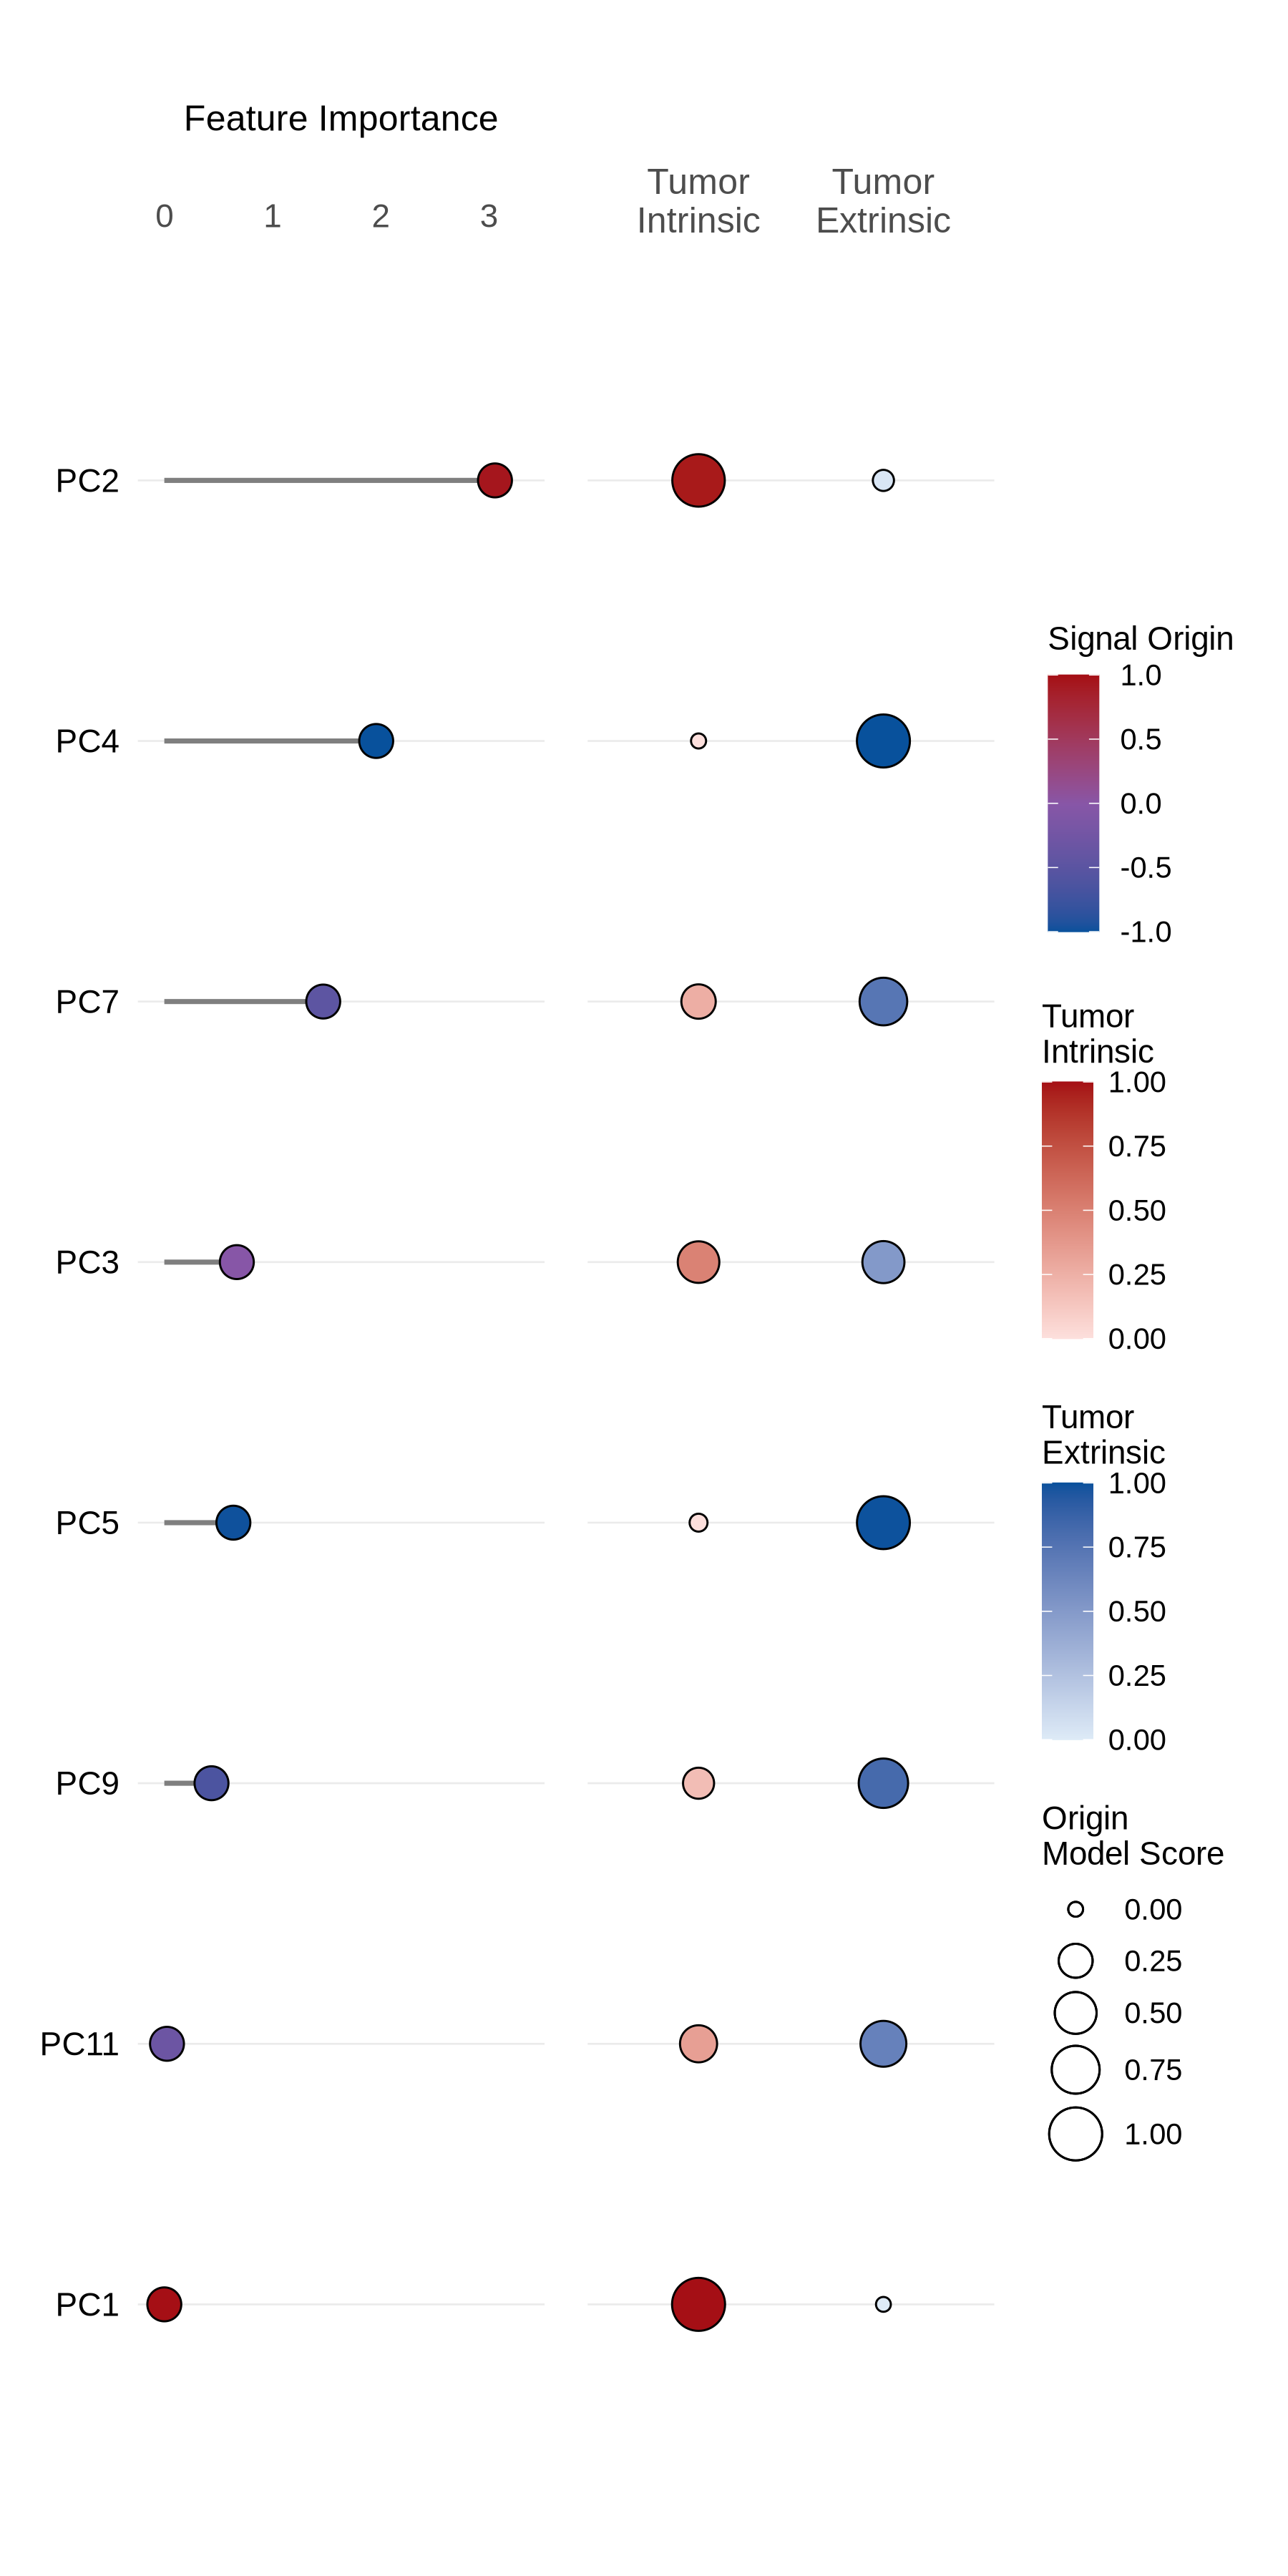

In [8]:
# ============================================================
# FIG 3g | FEATURE IMPORTANCE + MODELED SIGNAL ORIGIN

# ============================================================

library(tidyverse)
library(ggnewscale)
library(patchwork)

# ---- User arguments -------------------------------------------------------
n_features_to_plot <- 10
feature_prefixes   <- "ratio_pc"     # or "zscore_"

# Show features with modeled origin scores that LASSO zeroed out, for
# reference. Applies to the PC panel only.
show_zeroed        <- TRUE
zeroed_to_show     <- c("ratio_pc_01")   # NULL = all zeroed features

# ---- Origin scores: |beta| attenuation method -----------------------------
score_src <- origin_scores_atten %>%
  dplyr::select(feature, tumor_intrinsic, tumor_extrinsic, weak_unadj)

message("Plotting origin scores from: attenuation (|beta|) method")

# ---- Extract and scale coefficients (Mathios method) ----------------------
model_mathios <- readRDS("../../data/mathios_classifier_seq.rds")

orig_coefs <- coef(model_mathios$finalModel, s = model_mathios$bestTune$lambda) * (-1)

pr_mathios  <- prep(model_mathios$recipe)
traindat    <- model_mathios$trainingData %>%
  mutate(id = factor(id), type = factor(type))
model_input <- bake(pr_mathios, new_data = traindat)

feature_sds <- model_input %>%
  dplyr::select(-c(id, type)) %>% as.data.frame() %>% summarise_all(sd)

feature_coefs <- merge(
  data.frame(feature = names(feature_sds), sd = as.numeric(feature_sds)),
  data.frame(feature = rownames(orig_coefs), orig_coefs = as.numeric(orig_coefs)),
  by = "feature", all.x = TRUE
)
feature_coefs$scaled_coefs <- feature_coefs$orig_coefs * feature_coefs$sd

# ---- Left panel: feature importance ---------------------------------------
feature_regex <- paste0("^(", paste(feature_prefixes, collapse = "|"), ")")

# Retained features (non-zero LASSO coefficient)
retained_df <- feature_coefs %>%
  as_tibble() %>%
  filter(!is.na(scaled_coefs), scaled_coefs != 0) %>%
  filter(str_detect(feature, feature_regex)) %>%
  mutate(importance = abs(scaled_coefs), retained = TRUE) %>%
  arrange(desc(importance)) %>%
  slice_head(n = n_features_to_plot)

# Zeroed features: present in the model matrix and scored, coefficient == 0
zeroed_df <- feature_coefs %>%
  as_tibble() %>%
  filter(str_detect(feature, feature_regex)) %>%
  filter(is.na(scaled_coefs) | scaled_coefs == 0) %>%
  filter(feature %in% score_src$feature) %>%
  { if (!is.null(zeroed_to_show)) filter(., feature %in% zeroed_to_show) else . } %>%
  mutate(importance = 0, retained = FALSE)

if (!show_zeroed) zeroed_df <- zeroed_df[0, ]

# Zeroed features sort to the bottom (importance = 0)
importance_df <- bind_rows(retained_df, zeroed_df) %>%
  mutate(
    feature_type = case_when(
      str_detect(feature, "^ratio_pc_") ~ "PC",
      str_detect(feature, "^zscore_")   ~ "Z-score",
      TRUE ~ "Other"),
    feature_label = case_when(
      str_detect(feature, "^ratio_pc_") ~ gsub("ratio_pc_0?", "PC", feature),
      str_detect(feature, "^zscore_")   ~ gsub("zscore_", "Z ", feature),
      TRUE ~ feature),
    feature_label = ifelse(retained, feature_label,
                           paste0(feature_label, ""))
  ) %>%
  arrange(desc(importance)) %>%
  mutate(y_pos = n():1) %>%
  left_join(score_src, by = "feature") %>%
  mutate(ie_score = tumor_intrinsic - tumor_extrinsic)

if (any(is.na(importance_df$tumor_intrinsic))) {
  stop("Missing origin scores for: ",
       paste(importance_df$feature[is.na(importance_df$tumor_intrinsic)],
             collapse = ", "))
}

n_plotted <- nrow(importance_df)
message(sum(importance_df$retained), " retained, ",
        sum(!importance_df$retained), " zeroed features plotted.")

p_importance <- ggplot(importance_df, aes(x = importance, y = y_pos)) +
  # Stems for retained features only
  geom_segment(data = filter(importance_df, retained),
               aes(x = 0, xend = importance, yend = y_pos),
               color = "grey50", linewidth = 0.8) +
  # Retained: filled circles
  geom_point(data = filter(importance_df, retained),
             aes(fill = ie_score), shape = 21, size = 5,
             color = "black", stroke = 0.5) +
  # Zeroed: circles at zero importance
  geom_point(data = filter(importance_df, !retained),
             aes(fill = ie_score), shape = 21, size = 5,
             color = "black", stroke = 0.5, alpha = 1) +
  scale_fill_gradient2(
    low = "#08519C", mid = "#8856a7", high = "#A50F15",
    midpoint = 0, limits = c(-1, 1), name = "Signal Origin") +
  scale_y_continuous(breaks = importance_df$y_pos,
                     labels = importance_df$feature_label,
                     limits = c(0.5, n_plotted + 0.5)) +
  scale_x_continuous(expand = expansion(mult = c(0.08, 0.15)), position = "top") +
  labs(x = "Feature Importance", y = NULL, title = " ") +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.y = element_text(size = 11, colour = "black"),
    axis.text.x.top = element_text(size = 11),
    axis.title.x.top = element_text(size = 12, margin = margin(b = 10)),
    panel.grid.major.y = element_line(color = "grey92", linewidth = 0.3),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    legend.position = "right", legend.direction = "vertical",
    legend.title = element_text(size = 11), legend.text = element_text(size = 10),
    plot.title = element_text(size = 14, face = "bold", hjust = 0.5)
  ) +
  guides(fill = guide_colorbar(order = 1)) +
  coord_cartesian(clip = "off")

# ---- Right panel: intrinsic / extrinsic scores ----------------------------
ie_long <- importance_df %>%
  dplyr::select(feature, feature_label, y_pos, retained,
                tumor_intrinsic, tumor_extrinsic) %>%
  pivot_longer(c(tumor_intrinsic, tumor_extrinsic),
               names_to = "category", values_to = "score") %>%
  mutate(category = factor(
    ifelse(category == "tumor_intrinsic", "Tumor\nIntrinsic", "Tumor\nExtrinsic"),
    levels = c("Tumor\nIntrinsic", "Tumor\nExtrinsic"))) %>%
  filter(!is.na(y_pos))

p_ie <- ggplot(ie_long, aes(x = category, y = y_pos)) +
  geom_point(data = filter(ie_long, category == "Tumor\nIntrinsic"),
             aes(size = score, fill = score),
             shape = 21, color = "black", stroke = 0.5) +
  scale_fill_gradient(low = "#FDE0DD", high = "#A50F15", name = "Tumor\nIntrinsic",
                      limits = c(0, 1), guide = guide_colorbar(order = 1)) +
  ggnewscale::new_scale_fill() +
  geom_point(data = filter(ie_long, category == "Tumor\nExtrinsic"),
             aes(size = score, fill = score),
             shape = 21, color = "black", stroke = 0.5) +
  scale_fill_gradient(low = "#DEEBF7", high = "#08519C", name = "Tumor\nExtrinsic",
                      limits = c(0, 1), guide = guide_colorbar(order = 2)) +
  scale_size_continuous(range = c(2, 8), limits = c(0, 1),
                        name = "Origin\nModel Score",
                        guide = guide_legend(order = 3)) +
  scale_x_discrete(position = "top") +
  scale_y_continuous(limits = c(0.5, n_plotted + 0.5),
                     breaks = importance_df$y_pos, labels = NULL) +
  labs(x = NULL, y = NULL) +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x.top = element_text(size = 12),
    axis.text.y = element_blank(),
    panel.grid.major.y = element_line(color = "grey92", linewidth = 0.3),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(), panel.border = element_blank(),
    legend.position = "right", legend.direction = "vertical",
    legend.box = "vertical",
    legend.title = element_text(size = 11), legend.text = element_text(size = 10)
  ) +
  coord_cartesian(clip = "off")

combined_panel <- p_importance + p_ie +
  plot_layout(widths = c(1, 1), guides = "collect") &
  theme(legend.position = "right", legend.box = "vertical")

options(repr.plot.width = 6, repr.plot.height = 12, repr.plot.res = 300)
print(combined_panel)



In [9]:
ggsave(
  filename = "../../outputs/Fig3/Fig-Feature_importance_intrinsic_extrinsic-Ratio.png",
  plot = combined_panel,
  width = 6,
  height = 6,
  units = "in",
  dpi = 600,
  bg = "white",
    create.dir = TRUE
)